In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    print(files[:5])

/kaggle/input
[]
/kaggle/input/datasets
[]
/kaggle/input/datasets/vencerlanz09
[]
/kaggle/input/datasets/vencerlanz09/taco-dataset-yolo-format
['README.dataset.txt', 'README.roboflow.txt', 'data.yaml']
/kaggle/input/datasets/vencerlanz09/taco-dataset-yolo-format/valid
[]
/kaggle/input/datasets/vencerlanz09/taco-dataset-yolo-format/valid/labels
['000052_JPG_jpg.rf.37ee95937c69e8f097641e5487da719b.txt', '000095_jpg.rf.f04834eda4bb7582b4f7a8380b8676c9.txt', '000030_jpg.rf.8d4da2a81c714e7133277757eb4f8150.txt', '000111_JPG_jpg.rf.909d368cb4fb2db543eadafe9ed2b80c.txt', '000013_jpg.rf.c9273913862771c07071cc2920d1c886.txt']
/kaggle/input/datasets/vencerlanz09/taco-dataset-yolo-format/valid/images
['000118_JPG_jpg.rf.8809353b23c863ed7d52b139c3bdd2cf.jpg', '000021_JPG_jpg.rf.cc8a9b654b0fb3a89170fa88a91e938a.jpg', '000000_JPG_jpg.rf.7502211fb8242d7964e1ca87a3d02872.jpg', '000101_JPG_jpg.rf.93b2fb844cf5e3831c276c182b294421.jpg', '000003_JPG_jpg.rf.2e079b5980da7bb23d023b04fd723560.jpg']
/kaggle/in

In [9]:
BASE = "/kaggle/input/datasets/vencerlanz09/taco-dataset-yolo-format"

TRAIN_IMG = f"{BASE}/train/images"
TRAIN_LABEL = f"{BASE}/train/labels"

VALID_IMG = f"{BASE}/valid/images"
VALID_LABEL = f"{BASE}/valid/labels"

TEST_IMG = f"{BASE}/test/images"
TEST_LABEL = f"{BASE}/test/labels"

In [10]:
import yaml

with open(f"{BASE}/data.yaml", "r") as f:
    data = yaml.safe_load(f)

data

{'train': '../train/images',
 'val': '../valid/images',
 'test': '../test/images',
 'nc': 18,
 'names': ['Aluminium foil',
  'Bottle cap',
  'Bottle',
  'Broken glass',
  'Can',
  'Carton',
  'Cigarette',
  'Cup',
  'Lid',
  'Other litter',
  'Other plastic',
  'Paper',
  'Plastic bag - wrapper',
  'Plastic container',
  'Pop tab',
  'Straw',
  'Styrofoam piece',
  'Unlabeled litter'],
 'roboflow': {'workspace': 'divya-lzcld',
  'project': 'taco-mqclx',
  'version': 3,
  'license': 'CC BY 4.0',
  'url': 'https://universe.roboflow.com/divya-lzcld/taco-mqclx/dataset/3'}}

In [11]:
print("Number of classes:", data["nc"])
print("Classes:")
for i, name in enumerate(data["names"]):
    print(i, "->", name)

Number of classes: 18
Classes:
0 -> Aluminium foil
1 -> Bottle cap
2 -> Bottle
3 -> Broken glass
4 -> Can
5 -> Carton
6 -> Cigarette
7 -> Cup
8 -> Lid
9 -> Other litter
10 -> Other plastic
11 -> Paper
12 -> Plastic bag - wrapper
13 -> Plastic container
14 -> Pop tab
15 -> Straw
16 -> Styrofoam piece
17 -> Unlabeled litter


In [12]:
from collections import Counter

class_counts = Counter()

for file in os.listdir(TRAIN_LABEL):
    if file.endswith(".txt"):
        with open(os.path.join(TRAIN_LABEL, file), "r") as f:
            for line in f:
                if line.strip():
                    class_id = int(line.split()[0])
                    class_counts[class_id] += 1

for i, name in enumerate(data["names"]):
    print(f"{i:2} | {name:25} | {class_counts[i]}")

 0 | Aluminium foil            | 142
 1 | Bottle cap                | 1318
 2 | Bottle                    | 821
 3 | Broken glass              | 376
 4 | Can                       | 714
 5 | Carton                    | 662
 6 | Cigarette                 | 2214
 7 | Cup                       | 583
 8 | Lid                       | 252
 9 | Other litter              | 356
10 | Other plastic             | 751
11 | Paper                     | 369
12 | Plastic bag - wrapper     | 2228
13 | Plastic container         | 145
14 | Pop tab                   | 225
15 | Straw                     | 371
16 | Styrofoam piece           | 304
17 | Unlabeled litter          | 1419


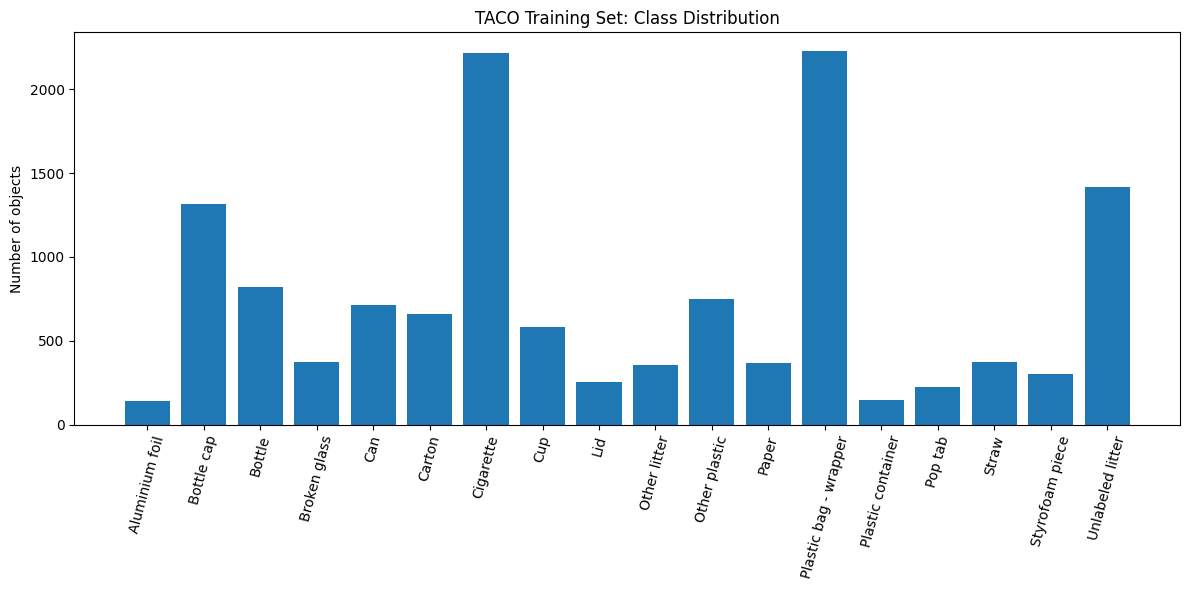

In [13]:
counts = [class_counts[i] for i in range(data["nc"])]

plt.figure(figsize=(12, 6))
plt.bar(data["names"], counts)

plt.xticks(rotation=75)
plt.ylabel("Number of objects")
plt.title("TACO Training Set: Class Distribution")
plt.tight_layout()
plt.show()

Loads of cigarettes, eh

In [14]:
!pip install -q ultralytics
from ultralytics import YOLO

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 4.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [15]:
model = YOLO("yolo11n.pt")

In [16]:
results = model.train(
    data=f"{BASE}/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    device=0
)

Ultralytics 8.4.163 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/vencerlanz09/taco-dataset-yolo-format/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


       2/30      2.78G       1.45      3.449      1.243         50        640: 100% ━━━━━━━━━━━━ 263/263 7.4it/s 35.3s0.3ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 54/54 5.7it/s 9.5s0.2s
                   all       1704       4830      0.199      0.184      0.073     0.0501

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/30      2.78G      1.442      3.173      1.219         30        640: 100% ━━━━━━━━━━━━ 263/263 7.6it/s 34.7s0.3ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 54/54 5.8it/s 9.3s0.2s
                   all       1704       4830      0.243      0.172      0.085     0.0553

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/30      2.78G      1.433       2.99      1.225         50        640: 100% ━━━━━━━━━━━━ 263/263 7.6it/s 34.7s0.2ss
                 Class     Ima

In [17]:
metrics = model.val(
    data=f"{BASE}/data.yaml",
    split="val",
    imgsz=640,
    batch=16,
    plots=True
)

Ultralytics 8.4.163 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11n summary (fused): 100 layers, 2,585,662 parameters, 0 gradients, 6.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 46.7±21.7 MB/s, size: 37.0 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /kaggle/input/datasets/vencerlanz09/taco-dataset-yolo-format/valid/labels... 1704 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1704/1704 789.5it/s 2.2s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/vencerlanz09/taco-dataset-yolo-format/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 107/107 7.2it/s 14.8s0.1s
                   all       1704       4830      0.496       0.32      0.329      0.246
        Aluminium foil         48         62      0.592      0.4

In [18]:
print("mAP50:    ", metrics.box.map50)
print("mAP50-95: ", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:   ", metrics.box.mr)

mAP50:     0.3288011087316931
mAP50-95:  0.24561241988140664
Precision: 0.4960905227088882
Recall:    0.319890556314502


In [21]:
for i, name in enumerate(data["names"]):
    print(
        f"{i:2} | {name:25} | "
        f"mAP50={metrics.box.ap50[i]:.3f} | "
        f"mAP50-95={metrics.box.ap[i]:.3f} |"
        f"no Of Instances= {class_counts[i]}"
        
    )

 0 | Aluminium foil            | mAP50=0.401 | mAP50-95=0.308 |no Of Instances= 142
 1 | Bottle cap                | mAP50=0.599 | mAP50-95=0.448 |no Of Instances= 1318
 2 | Bottle                    | mAP50=0.460 | mAP50-95=0.296 |no Of Instances= 821
 3 | Broken glass              | mAP50=0.055 | mAP50-95=0.031 |no Of Instances= 376
 4 | Can                       | mAP50=0.625 | mAP50-95=0.488 |no Of Instances= 714
 5 | Carton                    | mAP50=0.477 | mAP50-95=0.399 |no Of Instances= 662
 6 | Cigarette                 | mAP50=0.132 | mAP50-95=0.063 |no Of Instances= 2214
 7 | Cup                       | mAP50=0.485 | mAP50-95=0.396 |no Of Instances= 583
 8 | Lid                       | mAP50=0.326 | mAP50-95=0.252 |no Of Instances= 252
 9 | Other litter              | mAP50=0.223 | mAP50-95=0.177 |no Of Instances= 356
10 | Other plastic             | mAP50=0.183 | mAP50-95=0.123 |no Of Instances= 751
11 | Paper                     | mAP50=0.302 | mAP50-95=0.230 |no Of Insta

Clearly, working on Cigarettes should go a long way for us.. Also, let's see Unlabelled Litter vs Backround

In [22]:
# For our lovely smoky Cigarettes
from pathlib import Path

# Cigarette class ID
cigarette_id = 6

val_labels = Path(f"{BASE}/valid/labels")
val_images = Path(f"{BASE}/valid/images")

cigarette_images = []

for label_file in val_labels.glob("*.txt"):
    with open(label_file, "r") as f:
        labels = f.readlines()

    # Does this image contain at least one cigarette?
    if any(int(line.split()[0]) == cigarette_id for line in labels):
        cigarette_images.append(label_file.stem)

print("Validation images containing cigarettes:", len(cigarette_images))
print("Example:", cigarette_images[:10])

Validation images containing cigarettes: 223
Example: ['000086_JPG_jpg.rf.dd462eba3411e419feba1523ab797650', '000020_jpg.rf.a036efbf3b8530e43b004406a85cb5a5', '000042_JPG_jpg.rf.325c1b6dba8b53a7edce9fc4dc9014f5', '000065_jpg.rf.8c7031773ffbe8887cfedfe51f1e40d5', '000028_jpg.rf.89c4fd072a91e54530b00b7ae8e827ac', '000054_jpg.rf.2b3b61de7f13c0088c269f05428eaf6a', '000028_JPG_jpg.rf.b342419b70afb461c0e98f3cdb26daa0', '000066_jpg.rf.7547c0f4cb1dbf7121efa64b3b0c3698', '000082_JPG_jpg.rf.d7e2d001263bc2e1823b91eca120fa46', '000096_jpg.rf.469c2b50aade8d13d6748e986f6352b9']


In [26]:
len(list(val_images.glob("*.jpg")))

1704

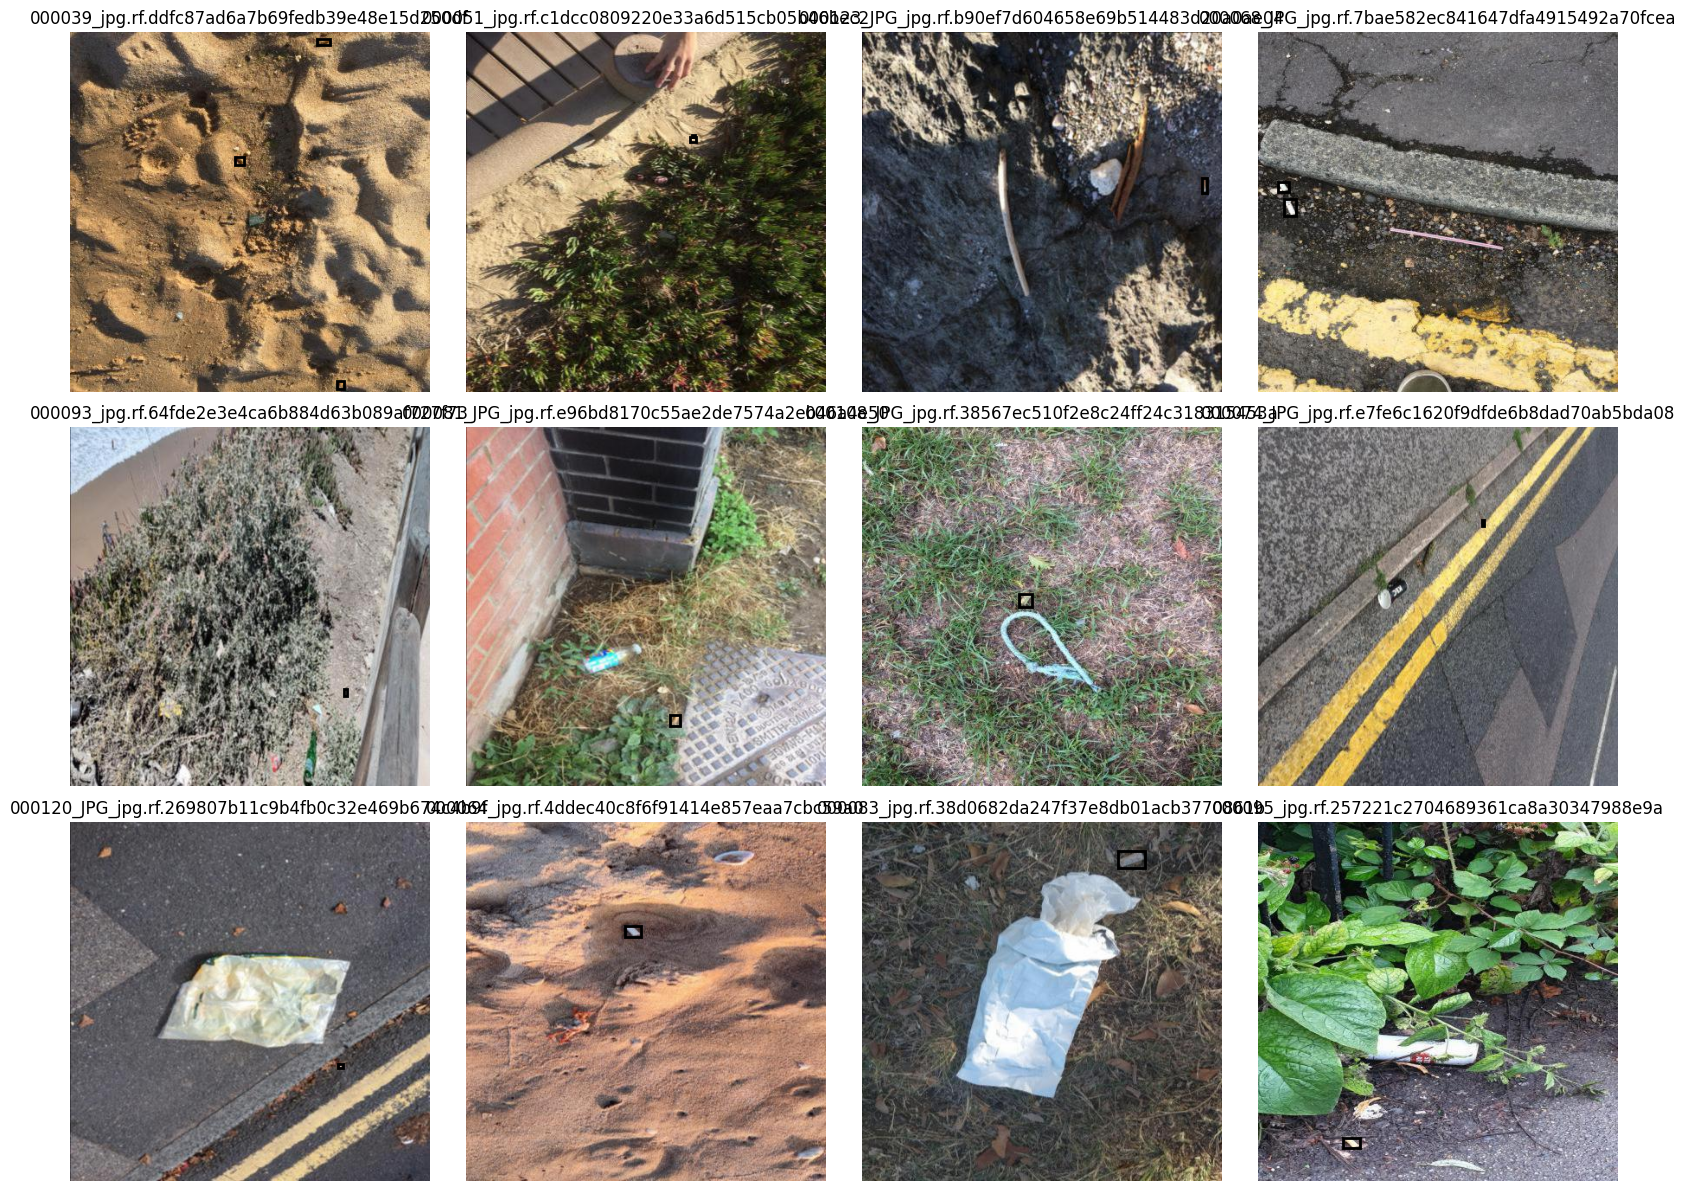

In [28]:
import random
from PIL import Image

samples = random.sample(cigarette_images, 12)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for ax, stem in zip(axes, samples):

    # Find image
    image_file = next(
        p for p in val_images.glob(f"{stem}.*")
    )

    img = Image.open(image_file)
    ax.imshow(img)

    # Read annotations
    label_file = val_labels / f"{stem}.txt"

    with open(label_file, "r") as f:
        lines = f.readlines()

    for line in lines:
        cls, xc, yc, w, h = map(float, line.split())

        if int(cls) == cigarette_id:

            W, H = img.size

            x1 = (xc - w/2) * W
            y1 = (yc - h/2) * H
            x2 = (xc + w/2) * W
            y2 = (yc + h/2) * H

            rect = plt.Rectangle(
                (x1, y1),
                x2-x1,
                y2-y1,
                fill=False,
                linewidth=2
            )

            ax.add_patch(rect)

    ax.set_title(stem)
    ax.axis("off")

plt.tight_layout()
plt.show()

Oh my god, most of these are impossible to recognize

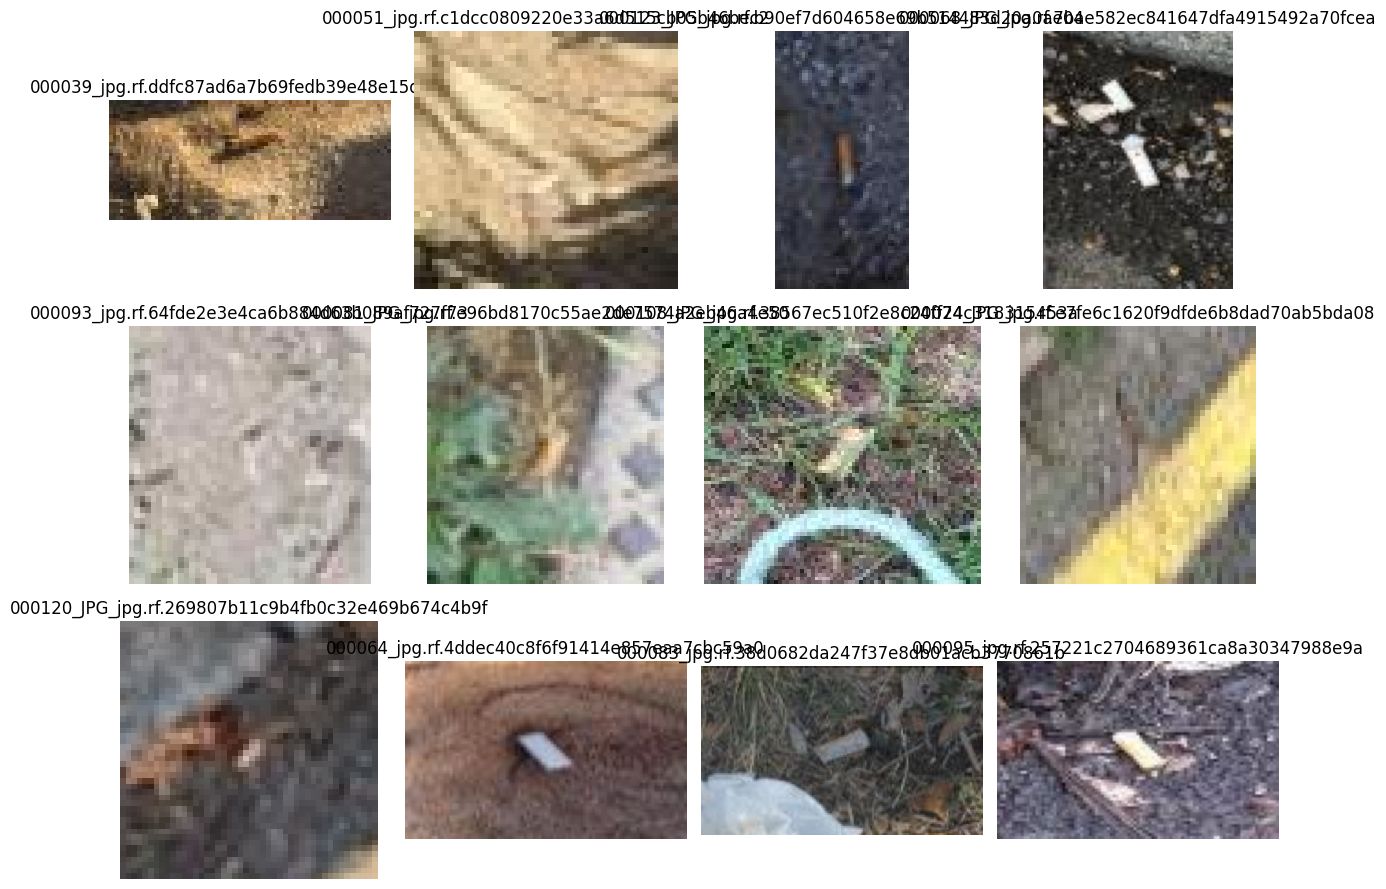

In [29]:
## Okay well, let's zoom in for a bit
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
axes = axes.flatten()

for ax, stem in zip(axes, samples):

    image_file = next(val_images.glob(f"{stem}.*"))
    img = Image.open(image_file)

    label_file = val_labels / f"{stem}.txt"

    with open(label_file, "r") as f:
        lines = f.readlines()

    # Find the first cigarette in this image
    for line in lines:
        cls, xc, yc, w, h = map(float, line.split())

        if int(cls) == cigarette_id:

            W, H = img.size

            x1 = int((xc - w/2) * W)
            y1 = int((yc - h/2) * H)
            x2 = int((xc + w/2) * W)
            y2 = int((yc + h/2) * H)

            # Add some padding around the box
            pad_x = max(20, int((x2 - x1) * 2))
            pad_y = max(20, int((y2 - y1) * 2))

            crop = img.crop((
                max(0, x1 - pad_x),
                max(0, y1 - pad_y),
                min(W, x2 + pad_x),
                min(H, y2 + pad_y)
            ))

            ax.imshow(crop)
            ax.set_title(stem)
            ax.axis("off")

            break

plt.tight_layout()
plt.show()

In [30]:
print(BASE)
print(val_images)
print(val_labels)

/kaggle/input/datasets/vencerlanz09/taco-dataset-yolo-format
/kaggle/input/datasets/vencerlanz09/taco-dataset-yolo-format/valid/images
/kaggle/input/datasets/vencerlanz09/taco-dataset-yolo-format/valid/labels


In [31]:
train_images = Path(f"{BASE}/train/images")
train_labels = Path(f"{BASE}/train/labels")

print(train_images)
print(train_labels)
print("Train images:", len(list(train_images.glob("*.*"))))
print("Train labels:", len(list(train_labels.glob("*.txt"))))

/kaggle/input/datasets/vencerlanz09/taco-dataset-yolo-format/train/images
/kaggle/input/datasets/vencerlanz09/taco-dataset-yolo-format/train/labels
Train images: 4200
Train labels: 4200


In [32]:
## We're gonna create a cigarette vs Background classifier
import shutil

# Cigarette-only dataset
CIG_BASE = Path("/kaggle/working/cigarette_dataset")

for split in ["train", "valid"]:
    (CIG_BASE / split / "images").mkdir(parents=True, exist_ok=True)
    (CIG_BASE / split / "labels").mkdir(parents=True, exist_ok=True)


def create_cigarette_split(split):
    images_dir = Path(f"{BASE}/{split}/images")
    labels_dir = Path(f"{BASE}/{split}/labels")

    out_images = CIG_BASE / split / "images"
    out_labels = CIG_BASE / split / "labels"

    n_images = 0
    n_cigarettes = 0

    for label_file in labels_dir.glob("*.txt"):

        cigarette_lines = []

        with open(label_file, "r") as f:
            for line in f:
                parts = line.strip().split()

                if not parts:
                    continue

                cls = int(parts[0])

                # Cigarette = class 6
                if cls == 6:
                    # Change class ID from 6 → 0
                    parts[0] = "0"
                    cigarette_lines.append(" ".join(parts))
                    n_cigarettes += 1

        # Only keep images that actually contain cigarettes
        if cigarette_lines:

            # Copy image
            image_file = next(images_dir.glob(f"{label_file.stem}.*"))
            shutil.copy2(
                image_file,
                out_images / image_file.name
            )

            # Save cigarette-only annotation
            with open(out_labels / label_file.name, "w") as f:
                f.write("\n".join(cigarette_lines) + "\n")

            n_images += 1

    print(f"{split}:")
    print(f"  Images:    {n_images}")
    print(f"  Cigarettes: {n_cigarettes}")


create_cigarette_split("train")
create_cigarette_split("valid")

train:
  Images:    683
  Cigarettes: 2214
valid:
  Images:    223
  Cigarettes: 565


In [33]:
print("Cigarette train images:",
      len(list((CIG_BASE / "train/images").glob("*.*"))))

print("Cigarette train labels:",
      len(list((CIG_BASE / "train/labels").glob("*.txt"))))

print("Cigarette valid images:",
      len(list((CIG_BASE / "valid/images").glob("*.*"))))

print("Cigarette valid labels:",
      len(list((CIG_BASE / "valid/labels").glob("*.txt"))))

Cigarette train images: 683
Cigarette train labels: 683
Cigarette valid images: 223
Cigarette valid labels: 223


In [34]:
cig_yaml = CIG_BASE / "cigarette.yaml"

with open(cig_yaml, "w") as f:
    f.write(f"""path: {CIG_BASE}
train: train/images
val: valid/images

nc: 1
names:
  0: cigarette
""")

print(cig_yaml)

/kaggle/working/cigarette_dataset/cigarette.yaml


In [35]:
print(cig_yaml.read_text())

path: /kaggle/working/cigarette_dataset
train: train/images
val: valid/images

nc: 1
names:
  0: cigarette



In [36]:
cig_model = YOLO("yolo11n.pt")

In [37]:
cig_results = cig_model.train(
    data=str(cig_yaml),
    epochs=30,
    imgsz=640,
    batch=16,
    device=0,
    name="cigarette_pretrain"
)

Ultralytics 8.4.163 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/cigarette_dataset/cigarette.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cigarette_pretrain, nbs=64,

In [38]:
cig_metrics = cig_model.val(
    data=str(cig_yaml),
    split="val",
    imgsz=640,
    batch=16,
    plots=True
)

Ultralytics 8.4.163 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1048.7±244.9 MB/s, size: 35.4 KB)
val: Scanning /kaggle/working/cigarette_dataset/valid/labels.cache... 223 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 223/223 93.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 4.5it/s 3.1s0.1s
                   all        223        565      0.455      0.273      0.259      0.116
Speed: 1.9ms preprocess, 4.1ms inference, 0.0ms loss, 3.4ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-2


In [39]:
print("mAP50:   ", cig_metrics.box.map50)
print("mAP50-95:", cig_metrics.box.map)
print("Precision:", cig_metrics.box.mp)
print("Recall:   ", cig_metrics.box.mr)

mAP50:    0.2591945604378337
mAP50-95: 0.11558506157229549
Precision: 0.45464729540114124
Recall:    0.27256637168141595


In [40]:
cig_best = cig_model.trainer.best
print(cig_best)

/kaggle/working/runs/detect/cigarette_pretrain/weights/best.pt


In [41]:
taco_transfer = YOLO(cig_best)

In [42]:
taco_transfer_results = taco_transfer.train(
    data=f"{BASE}/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    device=0,
    name="taco_cigarette_transfer"  
)

Ultralytics 8.4.163 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/vencerlanz09/taco-dataset-yolo-format/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/runs/detect/cigarette_pretrain/weights/best.pt, mom

Okay, yeah that was ridiculously bad

In [44]:
import random
import shutil

CIG_BG_BASE = Path("/kaggle/working/cigarette_bg_dataset")

for split in ["train", "valid"]:
    (CIG_BG_BASE / split / "images").mkdir(parents=True, exist_ok=True)
    (CIG_BG_BASE / split / "labels").mkdir(parents=True, exist_ok=True)

In [45]:
# Copy positive cigarette images + labels

for split in ["train", "valid"]:
    src_images = CIG_BASE / split / "images"
    src_labels = CIG_BASE / split / "labels"

    dst_images = CIG_BG_BASE / split / "images"
    dst_labels = CIG_BG_BASE / split / "labels"

    for image_file in src_images.glob("*.*"):
        shutil.copy2(image_file, dst_images / image_file.name)

    for label_file in src_labels.glob("*.txt"):
        shutil.copy2(label_file, dst_labels / label_file.name)

In [46]:
# Images with no Cigarette
train_images = Path(f"{BASE}/train/images")
train_labels = Path(f"{BASE}/train/labels")

negative_images = []

for label_file in train_labels.glob("*.txt"):

    has_cigarette = False

    with open(label_file, "r") as f:
        for line in f:
            parts = line.strip().split()

            if parts and int(parts[0]) == 6:
                has_cigarette = True
                break

    if not has_cigarette:
        negative_images.append(label_file.stem)

print("Available negative images:", len(negative_images))

Available negative images: 3517


In [47]:
random.seed(42)

negative_sample = random.sample(
    negative_images,
    len(list((CIG_BASE / "train/images").glob("*.*")))
)

print("Selected negatives:", len(negative_sample))

Selected negatives: 683


In [48]:
for stem in negative_sample:

    image_file = next(train_images.glob(f"{stem}.*"))

    shutil.copy2(
        image_file,
        CIG_BG_BASE / "train/images" / image_file.name
    )

    # Empty label file = no cigarette objects
    open(
        CIG_BG_BASE / "train/labels" / f"{stem}.txt",
        "w"
    ).close()

In [49]:
print("Train images:",
      len(list((CIG_BG_BASE / "train/images").glob("*.*"))))

print("Train labels:",
      len(list((CIG_BG_BASE / "train/labels").glob("*.txt"))))

Train images: 1366
Train labels: 1366


In [50]:
cig_bg_yaml = CIG_BG_BASE / "cigarette_bg.yaml"

with open(cig_bg_yaml, "w") as f:
    f.write(f"""path: {CIG_BG_BASE}
train: train/images
val: valid/images

nc: 1
names:
  0: cigarette
""")

print(cig_bg_yaml.read_text())

path: /kaggle/working/cigarette_bg_dataset
train: train/images
val: valid/images

nc: 1
names:
  0: cigarette



In [51]:
cig_bg_model = YOLO("yolo11n.pt")

cig_bg_results = cig_bg_model.train(
    data=str(cig_bg_yaml),
    epochs=30,
    imgsz=640,
    batch=16,
    device=0,
    name="cigarette_bg"
)

Ultralytics 8.4.163 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/cigarette_bg_dataset/cigarette_bg.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cigarette_bg, nbs=64,

In [52]:
cig_bg_best = cig_bg_model.trainer.best
print(cig_bg_best)

/kaggle/working/runs/detect/cigarette_bg/weights/best.pt


In [53]:
taco_cig_bg = YOLO(cig_bg_best)

In [54]:
taco_cig_bg_results = taco_cig_bg.train(
    data=f"{BASE}/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    device=0,
    name="taco_cig_bg_transfer"
)

Ultralytics 8.4.163 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/vencerlanz09/taco-dataset-yolo-format/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/runs/detect/cigarette_bg/weights/best.pt, momentum=

Yeah, no.. this is not cool at alll

In [ ]:
print(metrics.save_dir)

In [ ]:
print(os.listdir(metrics.save_dir))

In [ ]:
from PIL import Image
from IPython.display import display
import os

plot_files = [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "BoxPR_curve.png",
    "BoxP_curve.png",
    "BoxR_curve.png",
    "BoxF1_curve.png"
]

for filename in plot_files:
    path = os.path.join(metrics.save_dir, filename)

    print(filename)
    display(Image.open(path))

In [ ]:
for i, name in enumerate(data["names"]):
    print(
        f"{i:2} | {name:25} | "
        f"mAP50={metrics.box.ap50[i]:.3f} | "
        f"mAP50-95={metrics.box.ap[i]:.3f}"
    )

In [ ]:
print(f"mAP50:    {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall:    {metrics.box.mr:.4f}")

In [ ]:
#Let's grab, say, 12 validation images:
import random

val_images = [
    os.path.join(VALID_IMG, f)
    for f in os.listdir(VALID_IMG)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

sample_images = random.sample(val_images, 12)

pred_results = model.predict(
    source=sample_images,
    imgsz=640,
    conf=0.25,
    max_det=50
)

In [ ]:
from PIL import Image
from IPython.display import display

fig, axes= plt.subplots(3,4, figsize = (12, 15))
axes = axes.ravel()

for i,r in enumerate(pred_results):
    axes[i].imshow(r.plot()[:, :, ::-1])
    axes[i].axis("off")

plt.tight_layout()
plt.show()

Umm..definitely gotta improve on this